# Math for LLM
Linear algebra and probability from scratch, ending with a mini attention demo.
Every function is written by hand and checked against NumPy.

## Vectors and Embeddings
A vector is a list of numbers. An embedding is a vector that represents meaning.

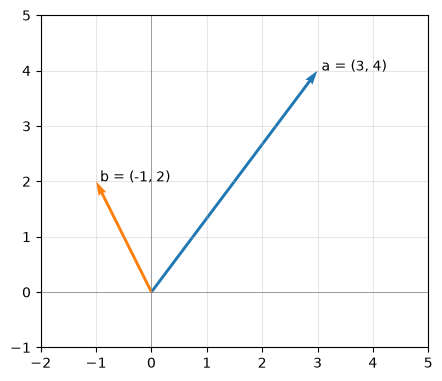

In [1]:
import numpy as np
import matplotlib.pyplot as plt

a = np.array([3,4])
b = np.array([-1,2])

fig, ax = plt.subplots(figsize=(5,5))
ax.quiver(0, 0, a[0], a[1], angles='xy', scale_units='xy', scale=1, color='tab:blue')
ax.quiver(0, 0, b[0], b[1], angles='xy', scale_units='xy', scale=1, color='tab:orange')
ax.text(a[0], a[1], " a = (3, 4)")
ax.text(b[0], b[1], " b = (-1, 2)")

ax.set_xlim(-2, 5)
ax.set_ylim(-1, 5)
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.show()

In [2]:
def magnitude(v):
    total = 0
    for x in v:
        total += x ** 2
    return total ** 0.5

print(magnitude(a))   # 5.0
assert np.allclose(magnitude(a), np.linalg.norm(a))


5.0


In [3]:
def normalize(v):
    m = magnitude(v)
    return np.array([x / m for x in v])

a_unit = normalize(a)
print(a_unit)              # [0.6 0.8]
print(magnitude(a_unit))   # 1.0
assert np.allclose(a_unit, a / np.linalg.norm(a))


[0.6 0.8]
1.0


In [4]:
#[royalty, male, female]
embeddings = {
    "king":   np.array([0.95, 0.85, 0.10]),
    "queen":  np.array([0.93, 0.12, 0.88]),
    "man":    np.array([0.10, 0.90, 0.05]),
    "woman":  np.array([0.08, 0.10, 0.92]),
    "prince": np.array([0.75, 0.80, 0.08]),
    "apple":  np.array([0.02, 0.05, 0.04]),
}

result = embeddings["king"] - embeddings["man"] + embeddings["woman"]
print(result)   # [0.93 0.05 0.97]


[0.93 0.05 0.97]


In [5]:
def distance(u, v):
    return magnitude(u - v)

for word, vec in embeddings.items():
    print(f"{word:7s} {distance(result, vec):.3f}")

closest = min(embeddings, key=lambda w: distance(result, embeddings[w]))
print("closest:", closest)


king    1.182
queen   0.114
man     1.503
woman   0.853
prince  1.178
apple   1.301
closest: queen


### Why this matters for LLMs
LLMs turn text into embeddings. Normalizing keeps only direction (meaning),
and finding the nearest vector is how semantic search and RAG retrieve documents.


## Dot Product and Cosine Similarity
How similar are two vectors? Cosine similarity compares direction only.

In [6]:
def dot_product(u, v):
    total = 0
    for x, y in zip(u, v):
        total += x * y
    return total

print(dot_product(a, b))   # 5
assert np.allclose(dot_product(a, b), np.dot(a, b))

5


In [7]:
def cosine_similarity(u, v):
    return dot_product(u, v) / (magnitude(u) * magnitude(v))

print(cosine_similarity(a, b))   # 0.447
expected = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
assert np.allclose(cosine_similarity(a, b), expected)


0.4472135954999579


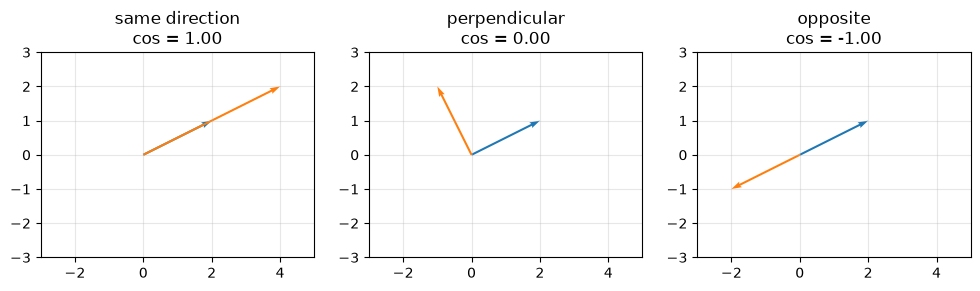

In [8]:
u = np.array([2, 1])
cases = {
    "same direction": np.array([4, 2]),
    "perpendicular":  np.array([-1, 2]),
    "opposite":       np.array([-2, -1]),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (title, v) in zip(axes, cases.items()):
    ax.quiver(0, 0, u[0], u[1], angles="xy", scale_units="xy", scale=1, color="tab:blue")
    ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1, color="tab:orange")
    ax.set_xlim(-3, 5)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.set_title(f"{title}\ncos = {cosine_similarity(u, v):.2f}")
plt.show()


In [9]:
p = np.array([3, 4])
q = np.array([1, 7])

print(cosine_similarity(p, q))                  # 0.877
print(dot_product(normalize(p), normalize(q)))  # 0.877
assert np.allclose(cosine_similarity(p, q), dot_product(normalize(p), normalize(q)))


0.8768124086713189
0.8768124086713189


In [10]:
#                                              [money, shipping, account]
docs = {
    "Refund policy: 14 days after purchase":   np.array([0.9, 0.1, 0.1]),
    "Track your package":                      np.array([0.1, 0.9, 0.1]),
    "Reset your password":                     np.array([0.1, 0.1, 0.9]),
    "Shipping fee refund for late delivery":   np.array([0.6, 0.7, 0.0]),
}
query = np.array([0.8, 0.2, 0.1])   # "How do I get my money back?"

scores = {text: cosine_similarity(query, vec) for text, vec in docs.items()}

for text, score in sorted(scores.items(), key=lambda item: item[1], reverse=True):
    print(f"{score:.3f}  {text}")


0.991  Refund policy: 14 days after purchase
0.810  Shipping fee refund for late delivery
0.357  Track your package
0.251  Reset your password


### Why this matters for LLMs
Cosine similarity is how RAG finds relevant documents for a question.
With normalized embeddings, dot product gives the same result and is faster.
